In [1]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT

sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

from sewing_pattern import (
    Stitch, StitchDict, SVGPanel, SewingPattern,
    ParameterizedSeamLine, ParameterizedEdgeLine,
    UnconstrainedFewViewLabel
)

c:\Users\HJP\anaconda3\envs\garmentcode\lib\site-packages\torch\nn\modules\transformer.py:20: UserWarning: Failed to initialize NumPy: DLL load failed while importing _multiarray_umath: 지정된 모듈을 찾을 수 없습니다. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:84.)
  device: torch.device = torch.device(torch._C._get_default_device()),  # torch.device('cpu'),


In [2]:
from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

sample_garment_path_list = glob(os.path.join("..", "sample_data", "*"))

In [9]:
import pickle
from PIL import Image


['..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\Dramatic__Custom_View_10_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\Dramatic__Custom_View_5_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\Dramatic__Custom_View_6_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\Dynamic_2__Custom_View_4_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\Dynamic__Custom_View_1_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\FV2_05__Custom_View_2_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\FV2_05__Custom_View_8_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\FV2_07__Custom_View_3_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\FV2_07__Custom_View_7_1_seam_line.pkl', '..\\sample_data\\rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01\\FV2_07__Custom_View_9_1_seam

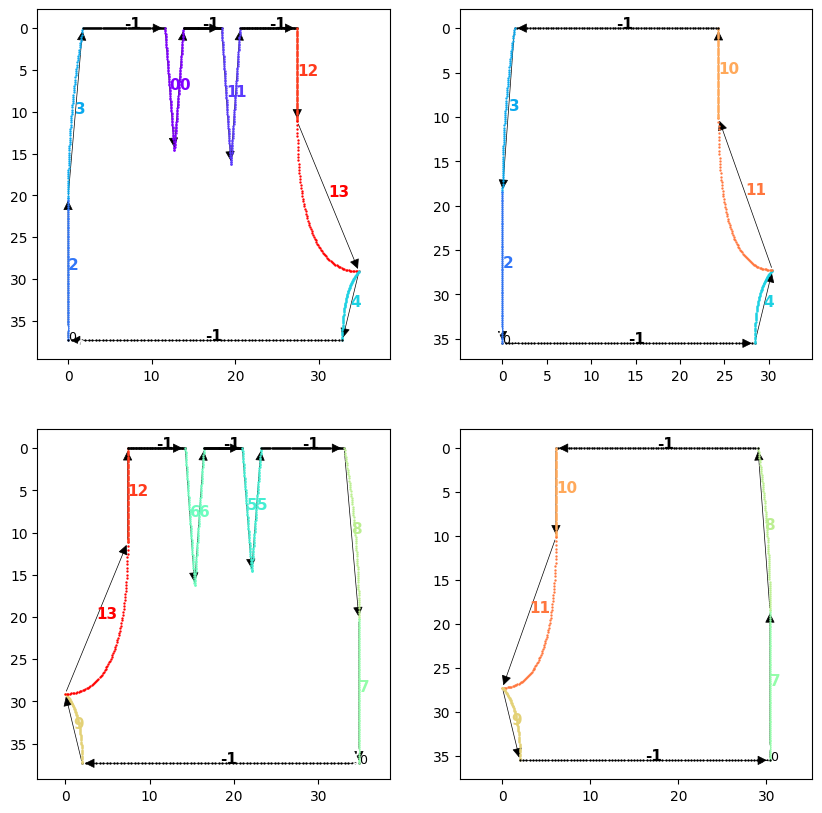

In [12]:
IDX = 9

garment_path = sample_garment_path_list[IDX]


seam_annotation_path_list = sorted(glob(os.path.join(garment_path, "*.pkl")))

print(seam_annotation_path_list)

seam_annotation_list = list(map(
    lambda x : pickle.load(open(x, "rb")),
    seam_annotation_path_list
))
image_list = list(map(
    lambda x : Image.open(x.replace("_seam_line.pkl", ".png")),
    seam_annotation_path_list
))

SPEC_PATH = list(filter(
    lambda x : "specification" in x,
    glob(
        os.path.join(
            os.path.dirname(seam_annotation_path_list[0]), "*.json"
        )
    )
))[0]

pattern = pyg.pattern.wrappers.VisPattern(SPEC_PATH)

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)

sewing_pattern.draw(
    plot_panel_name = False,
    # plot_stitch_name = False
)

In [14]:
# 수정 시 대칭으로 하도록 함.



dict_keys(['pant_b_r', 'pant_f_r', 'pant_b_l', 'pant_f_l'])

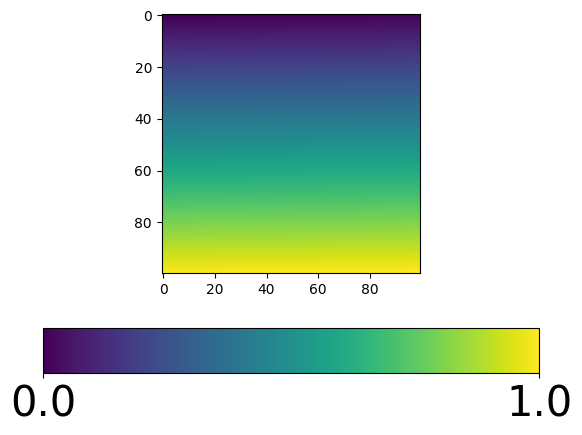

In [33]:
import matplotlib.pyplot as plt
import numpy as np


plt.imshow(np.linspace(0, 1, 10000).reshape(100, 100))
cbar = plt.colorbar(orientation='horizontal', aspect=11)  # Increased aspect ratio makes colorbar taller
cbar.set_ticks([0.0, 1.])
cbar.ax.tick_params(labelsize=30)  # Set font size of colorbar ticks to 14
cbar.ax.set_xticklabels(['{:.1f}'.format(x) for x in cbar.get_ticks()])  # Format as float
plt.show()